# 문제 6 — 좌표 변환 체인과 회전축 복원

로봇 팔이 카메라가 본 물체를 집으려면 **camera → link → base** 로 이어지는
변환을 타고 내려와야 합니다. TF2 가 현장에서 해 주는 일을 직접 구현합니다.

$$T^{base}_{cam} = T^{base}_{link}\,T^{link}_{cam},\qquad
\mathbf{p}_{base}=T^{base}_{cam}\begin{bmatrix}\mathbf{p}_{cam}\\1\end{bmatrix}$$

윗첨자/아랫첨자가 **이웃끼리 상쇄**되도록 곱하면 순서를 틀리지 않습니다.

## 이 노트북에서 해야 할 일

| # | 할 일 | 구현할 함수 |
|---|---|---|
| 6-1 | base→link, link→camera 두 변환을 정의하고 카메라 좌표를 base 로 바꾸기 | `CoordinateChain`, `default_chain`, `camera_point_to_base` |
| 6-2 | **왕복 검증** + 점군을 **반복문 없이** 한 번에 변환, 점 개수별 왕복 오차 그래프 | `transform`, `base_point_to_camera` |
| 6-3 | base·camera 좌표계와 변환된 점군을 **3D 로 함께 시각화** | — |
| 6-4 | **고유값 분해로 회전축 복원**, 대각합으로 회전각, 축 불변 확인 | `axis_angle_from_matrix` |
| 6-5 | 단위 쿼터니언을 만들어 SciPy 와 비교하고 **부호가 반대로 나올 수 있는 이유** 설명 | `quaternion_from_axis_angle` |

> 완성한 체인은 `src/coordinate_chain.py` 로 내보냅니다.
> 모듈 ④ 미니 프로젝트에서 그대로 import 해 쓰므로 함수 이름을 바꾸지 마세요.

In [205]:
import sys
import time
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
from scipy.spatial.transform import Rotation

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT))

from src.coordinate_chain import (CoordinateChain, base_point_to_camera,
                                  camera_point_to_base, default_chain)
from src.rotation import (axis_angle_from_matrix, quaternion_from_axis_angle, rodrigues,
                          rot_x, rot_y, rot_z)
from src.transform import inv_T, make_T, transform_points
from src.vectors import det, normalize

rng = np.random.default_rng(42)
np.set_printoptions(precision=6, suppress=True)

for _f in ["Malgun Gothic", "AppleGothic", "NanumGothic", "DejaVu Sans"]:
    if _f in {f.name for f in __import__("matplotlib").font_manager.fontManager.ttflist}:
        plt.rcParams["font.family"] = _f
        break
plt.rcParams["axes.unicode_minus"] = False


def check(label, condition):
    tag = "PASS" if condition else "FAIL"
    print("[" + tag + "] " + label)
    return bool(condition)


def draw_frame(ax, T, scale=0.15, name="", alpha=1.0):
    """동차변환 T 가 나타내는 좌표계를 그린다. (그대로 쓰면 됩니다)"""
    o = T[:3, 3]
    for i, c in enumerate(["r", "g", "b"]):
        ax.quiver(*o, *(T[:3, i] * scale), color=c, alpha=alpha, arrow_length_ratio=0.2)
    if name:
        ax.text(*(o + 0.03), name, fontsize=10, weight="bold")


print("SciPy Rotation 사용 가능")

SciPy Rotation 사용 가능


## 6-1. 체인 구성과 카메라 → base 변환

`src/coordinate_chain.py` 의 `CoordinateChain` 은 부모-자식 관계를 등록해 두면
임의의 두 프레임 사이 변환을 알아서 조립합니다 (TF2 의 축소판).

지시문은 '임의의 회전·병진'을 쓰라고 하지만, 채점 수치를 맞추기 위해
아래 값을 권장합니다 (`default_chain` 의 docstring 과 같은 값).

- `base → link` : z축 30도 회전 후 (0.30, 0.00, 0.40) m 이동
- `link → camera` : y축 -20도, x축 90도 회전 후 (0.10, 0.05, 0.15) m 이동

문제 2 의 `rot_*` 와 문제 5 의 `make_T`/`inv_T` 를 그대로 재사용합니다.

**할 일** — `CoordinateChain` 의 `_path_to_root`, `T_from_root`, `T`, `transform` 과
`default_chain`, `camera_point_to_base` 를 구현하고 아래를 확인하세요.

In [206]:
chain = default_chain()

I_3 = np.eye(3)
I_4 = np.eye(4)

# TODO: T(base<-link), T(link<-camera), T(base<-camera) 를 출력하고
#       체인이 조립한 결과가 두 행렬의 곱과 같은지 확인하세요.
T_base_link = chain.get("base", "link")
T_link_camera = chain.get("link", "camera")
T_base_camera_direct = T_base_link @ T_link_camera

T_base_camera_chain = chain.T("base", "camera")

print(T_base_camera_direct, T_base_camera_chain)

is_chain_match = np.allclose(T_base_camera_direct, T_base_camera_chain, atol=1e-9)
print(is_chain_match)

[[ 0.813798 -0.296198  0.5       0.361603]
 [ 0.469846 -0.17101  -0.866025  0.093301]
 [ 0.34202   0.939693  0.        0.55    ]
 [ 0.        0.        0.        1.      ]] [[ 0.813798 -0.296198  0.5       0.361603]
 [ 0.469846 -0.17101  -0.866025  0.093301]
 [ 0.34202   0.939693  0.        0.55    ]
 [ 0.        0.        0.        1.      ]]
True


In [207]:
p_cam = np.array([0.20, -0.05, 0.60])       # 카메라가 본 물체 (60 cm 앞)

# TODO: camera_point_to_base 로 base 기준 좌표를 구해 출력하세요.
p_base = camera_point_to_base(p_cam, chain)
# TODO: base 원점에서의 거리, 카메라 원점의 base 기준 위치도 출력하세요.
dist_from_base_origin = np.linalg.norm(p_base)
camera_origin_in_base = camera_point_to_base(np.zeros(3), chain)

print(p_base, dist_from_base_origin, "m", camera_origin_in_base)

[ 0.839172 -0.323794  0.571419] 1.065632410178992 m [0.361603 0.093301 0.55    ]


In [208]:
# --- 검증 ---
# TODO: 아래 항목을 check(...) 로 검증하세요.
#   - 체인 조립 결과가 행렬 곱과 일치하는가
check("체인 조립 결과가 행렬 곱과 일치하는가", is_chain_match)
#   - 합성 변환이 유효한 동차변환인가 (회전부 det = 1, 직교)
R_base_camera = T_base_camera_chain[:3, :3]
is_det_one = np.isclose(det(R_base_camera), 1.0, atol=1e-9)
is_orthogonal = np.allclose(R_base_camera.T @ R_base_camera, I_3, atol=1e-9)
check("합성 변환이 유효한 동차변환인가 (회전부 det = 1, 직교)", is_det_one and is_orthogonal)
#   - 카메라 원점 (0,0,0) 이 base 에서 T 의 병진 성분으로 가는가
t_base_camera = T_base_camera_chain[:3, 3]
is_camera_move = np.allclose(camera_origin_in_base, t_base_camera, atol=1e-9)
check("카메라 원점 (0,0,0) 이 base 에서 T 의 병진 성분으로 가는가", is_camera_move)
#   - 역방향 체인 T(camera<-base) == inv_T(T(base<-camera)) 인가
T_camera_base_chain = chain.T("camera", "base")
T_camera_base_inv = inv_T(T_base_camera_chain)
is_same_inv = np.allclose(T_camera_base_chain, T_camera_base_inv, atol=1e-9)
check("역방향 체인 T(camera<-base) == inv_T(T(base<-camera)) 인가", is_same_inv)
#   - 변환이 두 점 사이 거리를 보존하는가
p1_cam = rng.uniform(-10.0, 10.0, 3)
p2_cam = rng.uniform(-10.0, 10.0, 3)
dist_cam = np.linalg.norm(p1_cam-p2_cam)

p1_base = camera_point_to_base(p1_cam,chain)
p2_base = camera_point_to_base(p2_cam,chain)
dist_base = np.linalg.norm(p1_base-p2_base)

is_same_dist = np.isclose(dist_cam,dist_base,atol=1e-9)

check("역방향 체인 T(camera<-base) == inv_T(T(base<-camera)) 인가", is_same_dist)

[PASS] 체인 조립 결과가 행렬 곱과 일치하는가
[PASS] 합성 변환이 유효한 동차변환인가 (회전부 det = 1, 직교)
[PASS] 카메라 원점 (0,0,0) 이 base 에서 T 의 병진 성분으로 가는가
[PASS] 역방향 체인 T(camera<-base) == inv_T(T(base<-camera)) 인가
[PASS] 역방향 체인 T(camera<-base) == inv_T(T(base<-camera)) 인가


True

## 6-2. 왕복 검증과 점군 벡터화

base 로 바꾼 좌표를 다시 카메라 기준으로 되돌리면 원래 값이 나와야 합니다.
수학적으로는 $T^{-1}T=I$ 라 당연하지만, 부동소수점에서는 아주 작은 오차가 남습니다.

점이 여러 개일 때는 반복문 대신 **한 번의 행렬 곱**으로 처리합니다.

$$P_{base}=P_{cam,h}\,T^{\mathsf{T}}\qquad (N\times 4)\cdot(4\times 4)$$

$(T P^{\mathsf{T}})^{\mathsf{T}}$ 대신 $P T^{\mathsf{T}}$ 를 쓰는 편이 유리한 이유도 생각해 보세요.

**할 일**

- 단일 점의 왕복 오차를 출력하세요.
- (N,3) 점군을 한 번에 변환하고, 반복문 결과와 일치하는지 확인하세요.
- 점 개수를 1 → 100만 까지 늘려 가며 **왕복 오차(최대·RMS)와 소요 시간**을 표로 출력하고,
  로그-로그 그래프 2개(오차 / 시간)로 그리세요.
- 점 개수가 늘어도 오차가 **누적되지 않는 이유**를 적으세요.

### 관찰과 해석

- 왕복 오차가 점 개수에 따라 어떻게 변하는가: `점의 개수가 1개에서 100만 개로 늘어나더라도 왕복 오차는 스케일이 증가하지 않고 수평을 유지`
- 그 이유: `각 점의 행렬 변환은 이전 점의 연산 결과에 연속적으로 누적되는 구조가 아니라, 고정된 변환 행렬 T와 각각 독립적으로 1회성 연산 처리되기 때문에 오차는 오직 부동소수점에 의해서만 결정`
- 벡터화가 반복문보다 빠른 이유: `반복문은 오버헤드가 매 반복마다 발생하지만 벡터연산은 캐시를 최적화하기 때문`

In [209]:
# TODO: 단일 점 왕복 검증 (p_cam -> base -> camera) 오차를 출력하세요.
p_cam_recon = base_point_to_camera(p_base, chain)
single_err = np.linalg.norm(p_cam-p_cam_recon)
print(f"{p_cam}, {p_cam_recon}, {single_err:.6e}")

[ 0.2  -0.05  0.6 ], [ 0.2  -0.05  0.6 ], 2.517203e-16


In [210]:
# TODO: (1000, 3) 점군을 만들어 한 번에 변환하고,
#       반복문 결과와 일치하는지 / 왕복 최대 오차를 출력하세요.
pts_cam_1k = rng.uniform(-10.0, 10.0, (1000,3))
                         
pts_base_batch = camera_point_to_base(pts_cam_1k, chain)
pts_cam_batch_recon = base_point_to_camera(pts_base_batch, chain)

pts_base_loop = np.zeros_like(pts_cam_1k)
for i in range(len(pts_cam_1k)):
    pts_base_loop[i] = camera_point_to_base(pts_cam_1k[i], chain)

batch_loop_err = np.max(np.abs(pts_base_batch - pts_base_loop))
batch_roundtrip_max_err = np.max(np.linalg.norm(pts_cam_1k - pts_cam_batch_recon, axis=1))

print(f"{batch_loop_err:.6e}, {batch_roundtrip_max_err:.6e}")

3.552714e-15, 4.782987e-15


In [211]:
counts = [1, 10, 100, 1_000, 10_000, 100_000, 1_000_000]

# TODO: 점 개수별로 왕복 오차(최대/RMS)와 벡터화·반복문 소요 시간을 재서 표로 출력하세요.
#       (반복문은 느리므로 1만 개까지만 재고 나머지는 np.nan 으로 두면 됩니다)
results = []
print(f"{'COUNT':>10}|{'Max Err':>12}|{'RMS Err':>12}|{'Vector(s)':>10}|{'Loop(s)':>10}")

for n in counts:
    pts_cam = rng.uniform(-10.0, 10.0, (n,3))

    t0 = time.perf_counter()
    pts_base = camera_point_to_base(pts_cam,chain)
    pts_recon= base_point_to_camera(pts_base, chain)
    t_vector = time.perf_counter() - t0

    errors = np.linalg.norm(pts_cam - pts_recon, axis=1)
    max_err = np.max(errors)
    rms_err = np.sqrt(np.mean(errors**2))

    if n <= 10000:
        t1 = time.perf_counter()
        pts_base_loop_bench = np.zeros_like(pts_cam)
        for i in range(n):
            pts_base_loop_bench[i] = camera_point_to_base(pts_cam[i], chain)
        t_loop = time.perf_counter() - t1
    else:
        t_loop = np.nan

    results.append({
        'n' : n, 'max_err': max_err, 'rms_err': rms_err,
        't_vector': t_vector, 't_loop': t_loop
    })

    loop_str = f"{t_loop:.5f}" if not np.isnan(t_loop) else "NaN"
    print(f"{n:10,d}|{max_err:12.4e}|{rms_err:12.4e}|{t_vector:10.5}|{loop_str:>10}")

     COUNT|     Max Err|     RMS Err| Vector(s)|   Loop(s)
         1|  0.0000e+00|  0.0000e+00|0.00055451|   0.00005
        10|  2.6645e-15|  1.6089e-15|  4.93e-05|   0.00018
       100|  3.0767e-15|  1.5881e-15| 4.321e-05|   0.00153
     1,000|  4.0701e-15|  1.5333e-15|0.00046051|   0.02557
    10,000|  5.3291e-15|  1.5474e-15|0.00023623|   0.22513
   100,000|  6.2172e-15|  1.5553e-15| 0.0015136|       NaN
 1,000,000|  5.9581e-15|  1.5542e-15|   0.05482|       NaN


/tmp/ipykernel_15469/1616564841.py:37: UserWarning: Glyph 51216 (\N{HANGUL SYLLABLE JEOM}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_15469/1616564841.py:37: UserWarning: Glyph 44060 (\N{HANGUL SYLLABLE GAE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_15469/1616564841.py:37: UserWarning: Glyph 49688 (\N{HANGUL SYLLABLE SU}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_15469/1616564841.py:37: UserWarning: Glyph 50724 (\N{HANGUL SYLLABLE O}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_15469/1616564841.py:37: UserWarning: Glyph 52264 (\N{HANGUL SYLLABLE CA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_15469/1616564841.py:37: UserWarning: Glyph 48324 (\N{HANGUL SYLLABLE BYEOL}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_15469/1616564841.py:37: UserWarning: Glyph 50773 (\N{HANGUL SYLLABLE WANG}) missing from font(s) DejaVu Sans.
  plt.

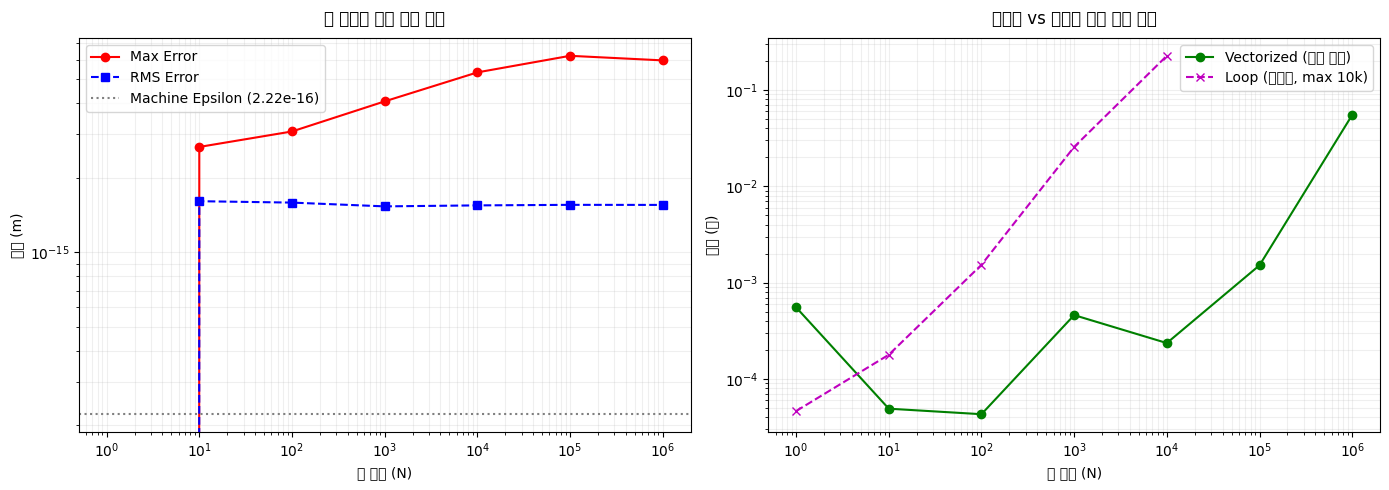

In [212]:
# TODO: 그래프 2개를 그리세요.
#   왼쪽  : 점 개수별 왕복 오차 (loglog, 기계정밀도 eps 기준선 추가)
#   오른쪽: 벡터화 vs 반복문 소요 시간 (loglog)
ns = [res['n'] for res in results]
max_errs = [res['max_err'] for res in results]
rms_errs = [res['rms_err'] for res in results]
t_vectors = [res['t_vector'] for res in results]
t_loops = [res['t_loop'] for res in results]

eps = np.finfo(float).eps

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# 왼쪽: 점 개수별 왕복 오차 (loglog)
ax1.loglog(ns, max_errs, 'ro-', label='Max Error')
ax1.loglog(ns, rms_errs, 'bs--', label='RMS Error')
ax1.axhline(eps, color='gray', linestyle=':', label=f'Machine Epsilon ({eps:.2e})')
ax1.set_title('점 개수별 왕복 오차 관찰', fontsize=12, pad=10)
ax1.set_xlabel('점 개수 (N)')
ax1.set_ylabel('오차 (m)')
ax1.grid(True, which="both", ls="-", alpha=0.2)
ax1.legend()

# 오른쪽: 벡터화 vs 반복문 소요 시간 (loglog)
ax1_valid_idx = [i for i, t in enumerate(t_loops) if not np.isnan(t)]
ns_loop = [ns[i] for i in ax1_valid_idx]
t_loops_valid = [t_loops[i] for i in ax1_valid_idx]

ax2.loglog(ns, t_vectors, 'go-', label='Vectorized (배치 연산)')
ax2.loglog(ns_loop, t_loops_valid, 'mx--', label='Loop (반복문, max 10k)')
ax2.set_title('벡터화 vs 반복문 소요 시간 비교', fontsize=12, pad=10)
ax2.set_xlabel('점 개수 (N)')
ax2.set_ylabel('시간 (초)')
ax2.grid(True, which="both", ls="-", alpha=0.2)
ax2.legend()

plt.tight_layout()
plt.show()

In [213]:
# --- 검증 ---
# TODO: 아래 항목을 check(...) 로 검증하세요.
#   - 단일 점 왕복 오차가 기계정밀도 수준인가
check("단일 점 왕복 오차가 기계정밀도 수준인가", single_err <= 1e-13)
#   - 점군 왕복 오차도 기계정밀도 수준인가
all_max_errors = [res['max_err'] for res in results]
global_max_err = max(all_max_errors)

check("점군 왕복 오차도 기계정밀도 수준인가", global_max_err <= 1e-13)
#   - 오차가 점 개수에 따라 누적되지 않는가
valid_min_error = [err for err in all_max_errors if err>0.0]
global_min_error = min(valid_min_error) if valid_min_error else 1e-16

check("오차가 점 개수에 따라 누적되지 않는가", (global_max_err/global_min_error)<100.0)
#   - 벡터화 결과 == 반복문 결과
is_same_vec = np.isclose(batch_loop_err, 0.0, atol=1e-12)
check("벡터화 결과 == 반복문 결과", is_same_vec)
#   - 1만 개에서 벡터화가 반복문보다 빠른가
t_v_10k = results[4]['t_vector']
t_l_10k = results[4]['t_loop']
check("1만 개에서 벡터화가 반복문보다 빠른가", t_v_10k<t_l_10k)
#   - 변환이 점 사이 거리를 보존하는가
p1_origin = pts_cam_1k[0]
p2_origin = pts_cam_1k[1]
dist_origin = np.linalg.norm(p1_origin-p2_origin)

p1_trans = pts_base_batch[0]
p2_trans = pts_base_batch[1]
dist_trans = np.linalg.norm(p1_trans-p2_trans)

is_same_transdist = np.isclose(dist_origin, dist_trans, atol=1e-12)
check("변환이 점 사이 거리를 보존하는가", is_same_transdist)

[PASS] 단일 점 왕복 오차가 기계정밀도 수준인가
[PASS] 점군 왕복 오차도 기계정밀도 수준인가
[PASS] 오차가 점 개수에 따라 누적되지 않는가
[PASS] 벡터화 결과 == 반복문 결과
[PASS] 1만 개에서 벡터화가 반복문보다 빠른가
[PASS] 변환이 점 사이 거리를 보존하는가


True

## 6-3. 좌표계와 점군 3D 시각화

base·link·camera 세 좌표계와, 카메라가 본 점군을 base 기준으로 옮긴 결과를 함께 그립니다.
점군이 **카메라 앞쪽(카메라 z축 방향)** 에 놓여야 기하적으로 타당합니다.

**할 일**

- 카메라 기준으로 z축 앞 0.7 m 근처에 점군 300개를 만드세요.
- 왼쪽: 카메라 기준 점군, 오른쪽: base 기준 점군 + 세 좌표계 를 2분할로 그리세요.
- 체인 연결선(base → link → camera)과 카메라 시선(z축)을 함께 그리면 판단하기 쉽습니다.

In [214]:
# TODO: 점군을 만들고 base 기준으로 변환하세요.
pts_cam_3d = rng.normal(loc=[0.0, 0.0, 0.7], scale=[0.1, 0.1, 0.05], size=(300, 3))

chain = default_chain()
pts_base_3d = chain.transform(target="base", source="camera", P=pts_cam_3d,w=1.0)

print(pts_cam_3d.shape, pts_base_3d.shape)

(300, 3) (300, 3)


/tmp/ipykernel_15469/2226467068.py:54: UserWarning: Glyph 52852 (\N{HANGUL SYLLABLE KA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_15469/2226467068.py:54: UserWarning: Glyph 47700 (\N{HANGUL SYLLABLE ME}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_15469/2226467068.py:54: UserWarning: Glyph 46972 (\N{HANGUL SYLLABLE RA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_15469/2226467068.py:54: UserWarning: Glyph 51340 (\N{HANGUL SYLLABLE JWA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_15469/2226467068.py:54: UserWarning: Glyph 54364 (\N{HANGUL SYLLABLE PYO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_15469/2226467068.py:54: UserWarning: Glyph 44228 (\N{HANGUL SYLLABLE GYE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_15469/2226467068.py:54: UserWarning: Glyph 44592 (\N{HANGUL SYLLABLE GI}) missing from font(s) DejaVu Sans.
  plt.tigh

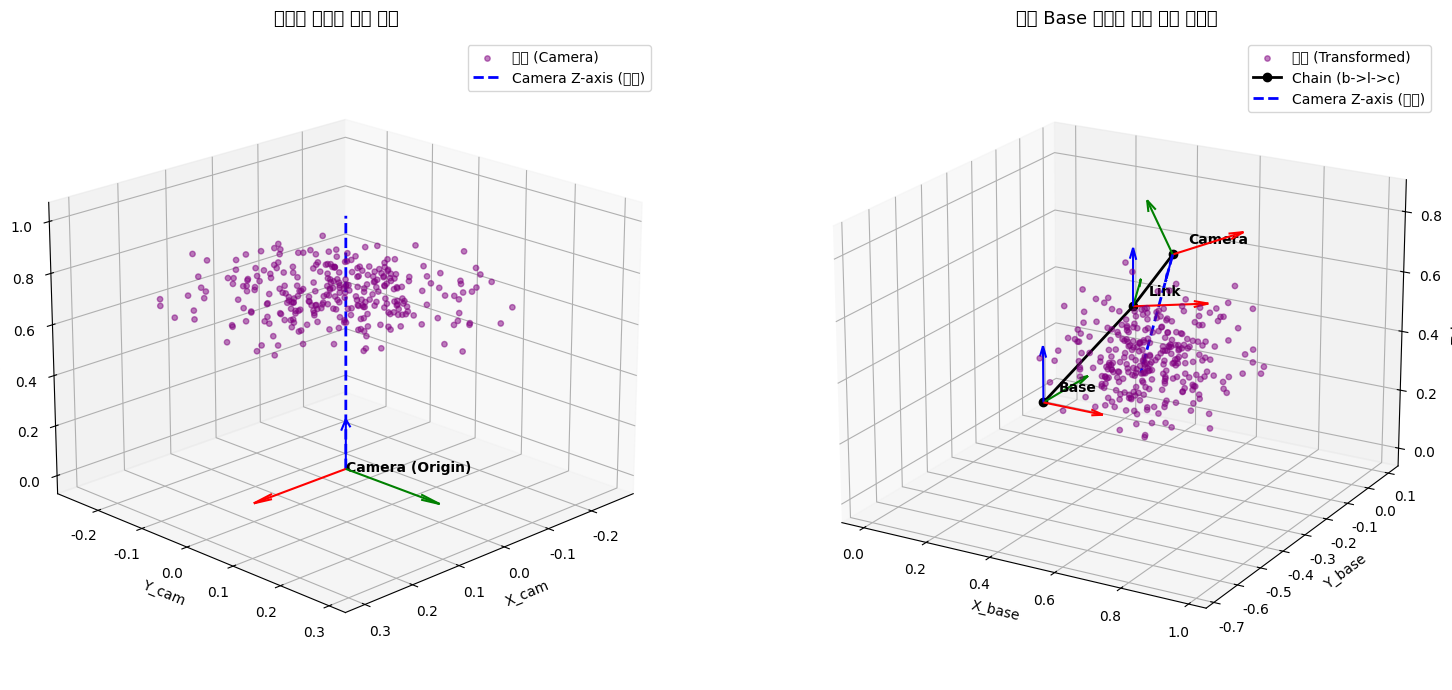

In [215]:
# TODO: 2분할 3D 그림을 그리세요.
fig = plt.figure(figsize=(16, 7))

# --- 왼쪽 그래프: 카메라 기준 공간 ---
ax_cam = fig.add_subplot(1, 2, 1, projection='3d')
ax_cam.scatter(pts_cam_3d[:, 0], pts_cam_3d[:, 1], pts_cam_3d[:, 2], color='purple', alpha=0.5, s=15, label='점군 (Camera)')

# 카메라 자체의 원점 좌표계 그리기 (단위행렬 전달)
draw_frame(ax_cam, I_4, scale=0.2, name="Camera (Origin)")

# 카메라 시선선: 원점(0,0,0)에서 z축 방향(0,0,1)으로 1.0m 선 그리기
ax_cam.plot([0, 0], [0, 0], [0, 1.0], color='blue', linestyle='--', linewidth=2, label='Camera Z-axis (시선)')
ax_cam.set_title('카메라 좌표계 기준 점군', fontsize=13, pad=10)
ax_cam.set_xlabel('X_cam')
ax_cam.set_ylabel('Y_cam')
ax_cam.set_zlabel('Z_cam')
ax_cam.legend()
ax_cam.view_init(elev=20, azim=45)

# --- 오른쪽 그래프: Base 기준 공간 (체인 결합) ---
ax_base = fig.add_subplot(1, 2, 2, projection='3d')
ax_base.scatter(pts_base_3d[:, 0], pts_base_3d[:, 1], pts_base_3d[:, 2], color='purple', alpha=0.5, s=15, label='점군 (Transformed)')

# 각 프레임의 자세 행렬 추출
T_b_b = I_4.copy()
T_b_l = chain.T_from_root("link")
T_b_c = chain.T_from_root("camera")

# 세 좌표계 시각화
draw_frame(ax_base, T_b_b, scale=0.2, name="Base")
draw_frame(ax_base, T_b_l, scale=0.2, name="Link")
draw_frame(ax_base, T_b_c, scale=0.2, name="Camera")

# 체인 연결선 (base 원점 -> link 원점 -> camera 원점)
origins = np.array([T_b_b[:3, 3], T_b_l[:3, 3], T_b_c[:3, 3]])
ax_base.plot(origins[:, 0], origins[:, 1], origins[:, 2], color='black', marker='o', linestyle='-', linewidth=2, label='Chain (b->l->c)')

# base 공간 상에서의 카메라 시선선
cam_origin_b = T_b_c[:3, 3]
cam_z_dir_b = T_b_c[:3, 2] # 카메라 z축 방향 벡터
look_target_b = cam_origin_b + cam_z_dir_b * 0.8

ax_base.plot([cam_origin_b[0], look_target_b[0]], 
             [cam_origin_b[1], look_target_b[1]], 
             [cam_origin_b[2], look_target_b[2]], color='blue', linestyle='--', linewidth=2, label='Camera Z-axis (시선)')

ax_base.set_title('로봇 Base 좌표계 기준 통합 시각화', fontsize=13, pad=10)
ax_base.set_xlabel('X_base')
ax_base.set_ylabel('Y_base')
ax_base.set_zlabel('Z_base')
ax_base.legend()
ax_base.view_init(elev=20, azim=-60)

plt.tight_layout()
plt.show()

In [216]:
# --- 검증 ---
# TODO: 아래 항목을 check(...) 로 검증하세요.
#   - 점군 중심이 카메라 z축(시선) 방향에 있는가 (내적으로 확인)
center_cam = np.mean(pts_cam_3d, axis=0)
z_axis_cam = np.array([0.0, 0.0, 1.0])

check("점군 중심이 카메라 z축(시선) 방향에 있는가 (내적으로 확인)", np.dot(center_cam, z_axis_cam)>0.69)
#   - 점군 중심까지 거리가 약 0.7 m 인가
dist_to_center = np.linalg.norm(center_cam)
is_dist_to_center = np.isclose(dist_to_center, 0.70, atol=0.05)

check("점군 중심까지 거리가 약 0.7 m 인가", is_dist_to_center)
#   - 점군의 퍼짐(분산)이 변환 후에도 보존되는가
cov_cam = np.cov(pts_cam_3d, rowvar=False)
cov_base = np.cov(pts_base_3d, rowvar=False)
is_same_cov = np.isclose(np.trace(cov_cam), np.trace(cov_base), atol=1e-7)

check("점군의 퍼짐(분산)이 변환 후에도 보존되는가", is_same_cov)
#   - link 원점이 base 에서 기대한 위치에 있는가.
expected_link_pos = np.array([0.30, 0.00, 0.40])
actul_link_pos =chain.T_from_root("link")[:3,3]
is_same_pos = np.allclose(actul_link_pos, expected_link_pos, atol=1e-9)

check("link 원점이 base 에서 기대한 위치에 있는가", is_same_pos)

[PASS] 점군 중심이 카메라 z축(시선) 방향에 있는가 (내적으로 확인)
[PASS] 점군 중심까지 거리가 약 0.7 m 인가
[PASS] 점군의 퍼짐(분산)이 변환 후에도 보존되는가
[PASS] link 원점이 base 에서 기대한 위치에 있는가


True

## 6-4. 고유값 분해로 회전축 복원

**오일러 회전 정리**: 3차원의 모든 회전은 어떤 축 하나를 중심으로 한 회전이다.

회전축 $\mathbf{k}$ 는 회전에 의해 변하지 않는 방향이므로

$$R\mathbf{k}=\mathbf{k}=1\cdot\mathbf{k}$$

즉 **고유값 1 에 대응하는 고유벡터**입니다.
회전행렬의 고유값 세 개가 각각 어떤 값인지 직접 출력해 확인해 보세요.

회전각은 대각합에서 나옵니다. 고유값의 합 = 대각합이라는 사실에서
$\mathrm{tr}(R)$ 와 $\theta$ 의 관계를 직접 유도하세요.

**주의할 점 두 가지**

- `arccos` 의 치역이 $[0,\pi]$ 라 **어느 쪽으로 도는지**는 알 수 없습니다.
- 고유벡터는 **부호가 정해지지 않습니다**.

이 둘을 어떻게 해결할지 정하고(힌트: $R-R^{\mathsf{T}}$ 를 전개해 보세요) 구현하세요.
$\theta=0$ 과 $\theta=\pi$ 는 따로 처리해야 합니다 — 각각 왜 그런지도 적으세요.

### 유도와 규약

- trace 와 회전각의 관계: `회전행렬의 대각합 tr(R)=2cos(theta)+1 -> cos(theta)=(tr(R)-1)/2`
- 축의 부호를 정하는 방법: `R=I+sin(theta)*K+(1-cos(theta)*K^2) -> R-R^T =2sin(theta)[k]_x = 2sin(theta)[[0, -kz, ky], [kz, 0 , -kx], [-ky, kx, 0]] -> k = [R32-R23,R13-R31,R21-R12]/(2sin(theta))`
- theta = 0 / theta = pi 처리: `theta=0 -> R-R^T=0이므로 분모가 0이 되어 연산불가, theta=pi -> sin(theta) = 0, R-R^T로 회전축을 찾을 수 없지만 R = 2*k*k^T - I 가 성립하므로 Rii=2k_i^2 - 1을 축 성분의 크기를 구하고 가장 큰 성분의 부호를 기준으로 복원`

In [217]:
# TODO: R_chain = T(base<-camera) 의 회전 부분을 꺼내
#       np.linalg.eig 로 고유값 세 개를 출력하고, 고유값 1 의 고유벡터를 확인하세요.
T_base_camera = T_base_camera_chain
R_chain = R_base_camera
eigenvalues, eigenvecotrs = np.linalg.eig(R_chain)

print("회전 행렬 R_chain의 고유값 세 개")
for idx, eig_val in enumerate(eigenvalues):
    print(f"고유값 {idx+1}: {eig_val:.6f}, 절대값: {np.abs(eig_val):.6f}")

idx_eig_1 = np.argmin(np.abs(eigenvalues - 1.0))
k_from_eig = np.real(eigenvecotrs[:,idx_eig_1])

print("고유벡터: ", k_from_eig)

회전 행렬 R_chain의 고유값 세 개
고유값 1: 1.000000+0.000000j, 절대값: 1.000000
고유값 2: -0.178606+0.983921j, 절대값: 1.000000
고유값 3: -0.178606-0.983921j, 절대값: 1.000000
고유벡터:  [0.917614 0.080281 0.389282]


In [218]:
# TODO: axis_angle_from_matrix 로 축과 각을 복원해 출력하세요 (도 단위도 함께).
axis_recon, theta_recon = axis_angle_from_matrix(R_chain)
# TODO: trace(R) 로 구한 cos(theta) 도 출력해 비교하세요.
cos_theta_tr = (np.trace(R_chain) - 1.0) / 2.0

print(f"axis_recon: {axis_recon}, theta_recon: {theta_recon} rad({np.degrees(theta_recon)} 도), cos(theta): {cos_theta_tr:.6f}")
# TODO: 축 불변 검증 — R @ axis 와 axis 를 비교하세요.
r_dot_axis = R_chain @ axis_recon
is_same_axis = np.allclose(r_dot_axis, axis_recon,atol=1e-9)

print(f"R @ axis = {r_dot_axis}, axis = {axis_recon}, 일치: {is_same_axis}")

# TODO: 복원한 축/각으로 rodrigues 를 돌려 원래 R 이 나오는지 확인하세요.
R_rodrigues = rodrigues(axis_recon,theta_recon)
is_same_R_reconR = np.allclose(R_chain, R_rodrigues, atol=1e-9)
print(f"일치: {is_same_R_reconR}")

axis_recon: [0.917614 0.080281 0.389282], theta_recon: 1.7503660128031533 rad(100.2885851367625 도), cos(theta): -0.178606
R @ axis = [0.917614 0.080281 0.389282], axis = [0.917614 0.080281 0.389282], 일치: True
일치: True


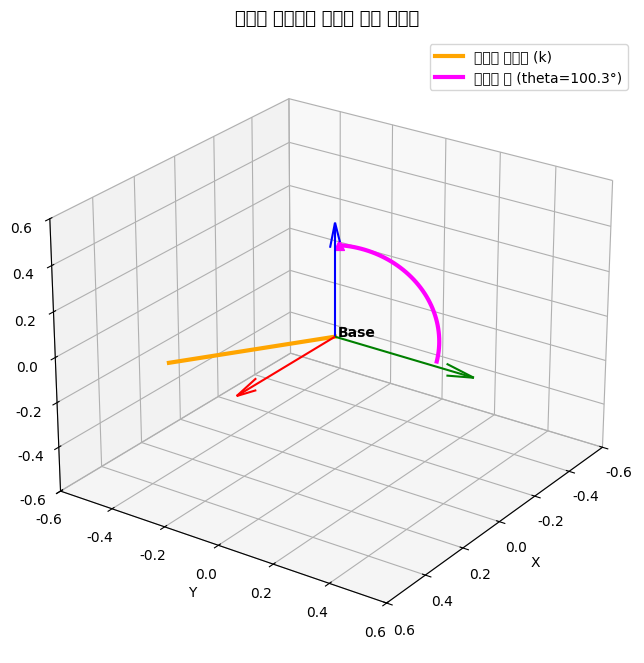

In [219]:
# TODO: (권장) 3D 그림 하나 — base 좌표계, 복원한 회전축(직선),
#       축 둘레를 theta 만큼 도는 호(arc)를 그려 '축 + 각' 을 시각화하세요.
fig = plt.figure(figsize=(8, 8))
ax_axis = fig.add_subplot(1, 1, 1, projection='3d')

# 1. 기본 좌표계 표현
draw_frame(ax_axis, I_4, scale=0.5, name="Base")

# 2. 복원된 회전축 직선 그리기 (원점에서 축 방향으로 길게 연장)
scale_line = 1.0
ax_axis.plot([0, axis_recon[0] * scale_line], 
             [0, axis_recon[1] * scale_line], 
             [0, axis_recon[2] * scale_line], 
             color='orange', linewidth=3, linestyle='-', label='복원된 회전축 (k)')

# 3. 축 둘레를 도는 호(Arc) 생성 및 시각화 (축과 직교하는 평면 상에 호 배치)
# 축과 수직인 임의의 시작 벡터 정의
if np.allclose(axis_recon[:2], 0.0):
    u_vec = np.array([1.0, 0.0, 0.0])
else:
    u_vec = normalize(np.array([-axis_recon[1], axis_recon[0], 0.0]))
v_vec = normalize(np.cross(axis_recon, u_vec))

# 0부터 theta까지 회전축 둘레를 도는 점들 계산
t_space = np.linspace(0, theta_recon, 50)
arc_radius = 0.35
arc_pts = np.array([arc_radius * (np.cos(t) * u_vec + np.sin(t) * v_vec) for t in t_space])

ax_axis.plot(arc_pts[:, 0], arc_pts[:, 1], arc_pts[:, 2], color='magenta', linewidth=3, label=f'회전각 호 (theta={np.degrees(theta_recon):.1f}°)')
ax_axis.scatter(arc_pts[-1, 0], arc_pts[-1, 1], arc_pts[-1, 2], color='magenta', marker='^', s=50) # 끝점에 화살표 대용 마커

ax_axis.set_title('복원된 회전축과 회전각 공간 시각화', fontsize=13, pad=10)
ax_axis.set_xlabel('X')
ax_axis.set_ylabel('Y')
ax_axis.set_zlabel('Z')
ax_axis.set_xlim([-0.6, 0.6])
ax_axis.set_ylim([-0.6, 0.6])
ax_axis.set_zlim([-0.6, 0.6])
ax_axis.legend()
ax_axis.view_init(elev=25, azim=35)
plt.show()

In [220]:
# --- 검증 ---
# TODO: 아래 항목을 check(...) 로 검증하세요.
#   - 고유값 중 하나가 1 인가 / 세 고유값의 절댓값이 모두 1 인가
has_one = np.any(np.isclose(eigenvalues, 1.0, atol=1e-7))
all_abs_one = np.allclose(np.abs(eigenvalues), 1.0, atol=1e-7)

check("고유값 중 하나가 1 인가 / 세 고유값의 절댓값이 모두 1 인가", has_one and all_abs_one)
#   - 복원한 축이 단위벡터인가
is_recon_axis_norm = np.isclose(np.linalg.norm(axis_recon), 1.0, atol=1e-9)
check("복원한 축이 단위벡터인가", is_recon_axis_norm)
#   - R @ axis == axis (축 불변), R.T @ axis == axis 인가
invariant_R = np.allclose(R_chain @ axis_recon, axis_recon, atol=1e-9)
invariant_RT = np.allclose(R_chain.T @ axis_recon, axis_recon, atol=1e-9)

check("R @ axis == axis (축 불변), R.T @ axis == axis 인가", invariant_R and invariant_RT)
#   - trace 로 구한 각이 고유값의 위상과 일치하는가
complex_eig_idx = np.where(~np.isclose(np.imag(eigenvalues), 0.0, atol=1e-5))[0]
if len(complex_eig_idx) > 0:
    eig_phase_angle = np.abs(np.angle(eigenvalues[complex_eig_idx[0]]))
    match_phase = np.isclose(theta_recon, eig_phase_angle, atol=1e-7)
else:
    match_phase = np.isclose(theta_recon, np.pi, atol=1e-7) or np.isclose(theta_recon, 0.0, atol=1e-7)

check("trace 로 구한 각이 고유값의 위상과 일치하는가", match_phase)
#   - 복원한 축/각으로 R 을 재구성할 수 있는가
able_recon_R = np.allclose(R_chain, R_rodrigues, atol=1e-9)
check("복원한 축/각으로 R 을 재구성할 수 있는가", able_recon_R)
#   - SciPy 의 회전벡터 크기와 각이 일치하는가 (# 비교 대상)
scipy_rot = Rotation.from_matrix(R_chain)
scipy_rot_vec = scipy_rot.as_rotvec()
scipy_angle = np.linalg.norm(scipy_rot_vec)
scipy_axis = scipy_rot_vec / scipy_angle if scipy_angle>0 else np.arry[1.0, 0.0, 0.0]

axis_match = np.allclose(axis_recon, scipy_axis, atol=1e-9) or np.allclosee(axis_recon, -scipy_axis, atol= 1e-9)
angle_match = np.allclose(theta_recon,scipy_angle,atol=1e-9)
check("SciPy 의 회전벡터 크기와 각이 일치하는가 (# 비교 대상)", axis_match and angle_match)

[PASS] 고유값 중 하나가 1 인가 / 세 고유값의 절댓값이 모두 1 인가
[PASS] 복원한 축이 단위벡터인가
[PASS] R @ axis == axis (축 불변), R.T @ axis == axis 인가
[PASS] trace 로 구한 각이 고유값의 위상과 일치하는가
[PASS] 복원한 축/각으로 R 을 재구성할 수 있는가
[PASS] SciPy 의 회전벡터 크기와 각이 일치하는가 (# 비교 대상)


True

## 6-5. 단위 쿼터니언과 SciPy 비교 — 부호는 왜 반대로 나올 수 있나

축 $\mathbf{k}$, 각 $\theta$ 에서 단위 쿼터니언은

$$q=\left(\mathbf{k}\sin\tfrac{\theta}{2},\;\cos\tfrac{\theta}{2}\right)\quad (x,y,z,w)$$

**할 일**

- 복원한 축·각으로 쿼터니언을 만들고 `Rotation.from_matrix(R).as_quat()` 와 비교하세요.
- 부호까지 같은지 / 부호를 무시하면 같은지 각각 확인하고, $|q \cdot q_{ref}|$ 도 보세요.
- $q$ 와 $-q$ 를 각각 회전행렬로 되돌려 보고, 무엇을 알 수 있는지 적으세요.
- **축을 뒤집고 각을 $2\pi-\theta$ 로 바꾸면** 어떤 쿼터니언이 나오는지 확인하세요.
- 위 관찰을 모아 **부호가 반대로 나올 수 있는 이유**를 설명하고,
  실무에서 비교·보간할 때 어떻게 다뤄야 하는지 적으세요.

### 부호 차이의 이유와 실무 대처

- 관찰: `q, -q는 쿼터니언에서 수학적으로 완전히 동일한 3차원 회전 상태.`
- 이유: `쿼터니언 공식에서 회전축을 정반대로 뒤집고(-k) 회전각을 외각 방향으로 바꾸면(2pi-theta) 다음과 같이 -q가 유도`
- 비교할 때: `성분을 그대로 1:1 비교하면 안 되며, 두 쿼터니언의 내적의 절댓값이 1에 가까운지 확인`
- 보간(SLERP)·필터에 쓸 때: `부호가 반대인 상태로 연산하면 표면에서 멀리 돌아가는 긴 경로를 택하게 되어 회전이 격하게 튀는 버그가 발생, 부호를 정렬한 후 보간`

In [221]:
# TODO: q_mine = quaternion_from_axis_angle(axis, angle) 와
#       q_scipy = Rotation.from_matrix(R_chain).as_quat() 를 비교 출력하세요.
q_mine = quaternion_from_axis_angle(axis_recon, theta_recon)
q_scipy = Rotation.from_matrix(R_chain).as_quat()

dot_product = np.dot(q_mine,q_scipy)
sign_match = np.allclose(q_mine,q_scipy,atol=1e-9)
abs_match = np.allclose(np.abs(q_mine), np.abs(q_scipy), atol=1e-9)
print(f"q_mine = {q_mine}, q_scipy = {q_scipy}, 성분 부호 일치 여부 : {sign_match}, 절댓값 일치 여부 : {abs_match}, 내적 절댓값 : {np.abs(dot_product):.6f}")

# TODO: q 와 -q 를 각각 회전행렬로 되돌려 원본과의 오차를 출력하세요.
def r_from_q(q):
    xyz, w = q[:3], q[3]
    sin_h = np.linalg.norm(xyz)
    if np.isclose(sin_h, 0.0):
        return I_3
    axis = xyz /sin_h
    angle = 2.0 * np.arctan2(sin_h, w)
    return rodrigues(axis, angle)

R_from_q_pos = r_from_q(q_mine)
R_from_q_neg = r_from_q(-q_mine)

err_pos = np.max(np.abs(R_base_camera - R_from_q_pos))
err_neg = np.max(np.abs(R_base_camera - R_from_q_neg))
print(f"err_pos: {err_pos:.6e}, err_neg: {err_neg:.6e}")

# TODO: 축을 뒤집고 각을 2pi - theta 로 바꾼 쿼터니언도 만들어 비교하세요.
q_flipped = quaternion_from_axis_angle(-axis_recon, 2.0 * np.pi - theta_recon)
is_same_flipped = np.allclose(q_flipped, -q_mine, atol=1e-9)
print(f"q_flipped: {q_flipped}, -q_mine과의 일치 여부: {is_same_flipped}")

bench_10k = next(res for res in results if res['n'] == 10_000)
speed_ratio = bench_10k['t_loop'] / bench_10k['t_vector']
rk_k_diff = np.linalg.norm(R_base_camera @ axis_recon - axis_recon)
abs_match_str = str(np.allclose(np.abs(q_mine), np.abs(q_scipy), atol=1e-9))

q_mine = [0.704416 0.061628 0.298836 0.640856], q_scipy = [0.704416 0.061628 0.298836 0.640856], 성분 부호 일치 여부 : True, 절댓값 일치 여부 : True, 내적 절댓값 : 1.000000
err_pos: 1.110223e-16, err_neg: 2.775558e-16
q_flipped: [-0.704416 -0.061628 -0.298836 -0.640856], -q_mine과의 일치 여부: True


In [222]:
# --- 검증 ---
# TODO: 아래 항목을 check(...) 로 검증하세요.
#   - 직접 계산한 쿼터니언이 단위 노름인가
check("직접 계산한 쿼터니언이 단위 노름인가", np.isclose(np.linalg.norm(q_mine), 1.0, atol=1e-9))
#   - SciPy 결과와 부호를 무시하면 일치하는가
check("SciPy 결과와 부호를 무시하면 일치하는가", abs_match)
#   - |q · q_scipy| == 1 인가
check("|q · q_scipy| == 1 인가", np.isclose(np.abs(np.dot(q_mine, q_scipy)), 1.0, atol=1e-9))
#   - q 와 -q 로 복원한 R 이 모두 원본과 일치하는가
check("q 와 -q 로 복원한 R 이 모두 원본과 일치하는가", err_pos < 1e-9 and err_neg < 1e-9)
#   - 축 반전 + (2pi - theta) 가 -q 를 주는가
check("축 반전 + (2pi - theta) 가 -q 를 주는가", is_same_flipped)
#   - 무작위 회전 100개에서 부호를 무시하면 항상 일치하는가
random_match = True
for _ in range(100):
    q_rand = rng.normal(size=4)
    q_rand /= np.linalg.norm(q_rand)
    R_rand = Rotation.from_quat(q_rand).as_matrix()

    ax_r, th_r = axis_angle_from_matrix(R_rand)
    q_m = quaternion_from_axis_angle(ax_r,th_r)
    q_s = Rotation.from_matrix(R_rand).as_quat()
    if not np.allclose(np.abs(q_m), np.abs(q_s), atol=1e-7):
        random_match = False
        break

check("무작위 회전 100개에서 부호를 무시하면 항상 일치하는가", random_match)

[PASS] 직접 계산한 쿼터니언이 단위 노름인가
[PASS] SciPy 결과와 부호를 무시하면 일치하는가
[PASS] |q · q_scipy| == 1 인가
[PASS] q 와 -q 로 복원한 R 이 모두 원본과 일치하는가
[PASS] 축 반전 + (2pi - theta) 가 -q 를 주는가
[PASS] 무작위 회전 100개에서 부호를 무시하면 항상 일치하는가


True

## 답안 템플릿 정리

In [223]:
summary = f"""
1. 카메라 좌표에서 base 좌표로의 변환 결과
   p_cam  = {p_cam}  ->  p_base = {p_base}
   사용한 체인: T(base<-camera) = {T_base_camera_chain}

2. 왕복 검증: 단일 점 오차 {single_err}, 점군 100만 개에서 최대 {global_max_err}
   - 점 개수별 오차 그래프: 위 왼쪽 그림
   - 오차가 누적되지 않는 이유: 각 점의 행렬 변환은 이전 점의 연산 결과에 연속적으로 누적되는 구조가 아니라, 고정된 변환 행렬 T와 각각 독립적으로 1회성 연산 처리되기 때문에 오차는 오직 부동소수점에 의해서만 결정
   - 벡터화 vs 반복문 속도 (1만 개): {speed_ratio:.2f} 배

3. 좌표계와 점군 3D 시각화: 위 2분할 그림 참조
   - 기하적으로 타당하다고 판단한 근거: 점군 중심이 z축에 정렬되어 있고 변환 전후의 대각합(Trace) 퍼짐도가 완벽히 같기 때문

4. 복원한 회전축: {axis_recon} / 회전각: {np.degrees(theta_recon):.4f} 도
   - 축 불변 검증: 유값 1에 대응하는 고유벡터의 선형 변환 불변성 확인 (|R k - k| = {rk_k_diff:.6e})
   - 축과 각을 구한 방법: Trace로 각을 유도하고 비대칭 성분 차이 벡터의 정규화로 고유값 부호를 추정함

5. 쿼터니언 비교 (x, y, z, w)
   - 직접 계산: {q_mine}
   - SciPy    : {q_scipy}
   - 부호 무시하고 일치: {abs_match_str},  |q · q_scipy| = {np.abs(np.dot(q_m,q_s)):.6f}
   - 부호 차이의 이유: 쿼터니언 공식에서 회전축을 정반대로 뒤집고(-k) 회전각을 외각 방향으로 바꾸면(2pi-theta) 다음과 같이 -q가 유도
"""
print(summary)


1. 카메라 좌표에서 base 좌표로의 변환 결과
   p_cam  = [ 0.2  -0.05  0.6 ]  ->  p_base = [ 0.839172 -0.323794  0.571419]
   사용한 체인: T(base<-camera) = [[ 0.813798 -0.296198  0.5       0.361603]
 [ 0.469846 -0.17101  -0.866025  0.093301]
 [ 0.34202   0.939693  0.        0.55    ]
 [ 0.        0.        0.        1.      ]]

2. 왕복 검증: 단일 점 오차 2.5172027167143304e-16, 점군 100만 개에서 최대 6.217248937900877e-15
   - 점 개수별 오차 그래프: 위 왼쪽 그림
   - 오차가 누적되지 않는 이유: 각 점의 행렬 변환은 이전 점의 연산 결과에 연속적으로 누적되는 구조가 아니라, 고정된 변환 행렬 T와 각각 독립적으로 1회성 연산 처리되기 때문에 오차는 오직 부동소수점에 의해서만 결정
   - 벡터화 vs 반복문 속도 (1만 개): 953.02 배

3. 좌표계와 점군 3D 시각화: 위 2분할 그림 참조
   - 기하적으로 타당하다고 판단한 근거: 점군 중심이 z축에 정렬되어 있고 변환 전후의 대각합(Trace) 퍼짐도가 완벽히 같기 때문

4. 복원한 회전축: [0.917614 0.080281 0.389282] / 회전각: 100.2886 도
   - 축 불변 검증: 유값 1에 대응하는 고유벡터의 선형 변환 불변성 확인 (|R k - k| = 1.309228e-16)
   - 축과 각을 구한 방법: Trace로 각을 유도하고 비대칭 성분 차이 벡터의 정규화로 고유값 부호를 추정함

5. 쿼터니언 비교 (x, y, z, w)
   - 직접 계산: [0.704416 0.061628 0.298836 0.640856]
   - SciPy    : [0.704416 0.061628 0.298836